### Perceptron

`-` 신경망: 뉴런(전기적인 방법으로 신호전달)들의 집합

`-` 인공신경망: 뉴런과 비슷한 방식을 수학적으로 구현하고 이걸 묶으면 사람처럼 사고할 수 있는 컴퓨터가 만들어지지 않을까? 

`-` 인공신경망의 아키텍처 

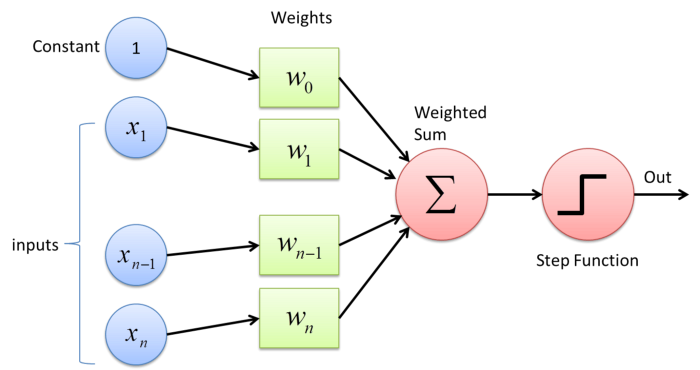  
   - 이미지출처: https://towardsdatascience.com/what-the-hell-is-perceptron-626217814f53

- 이 그림은 하나의 observation에 대한 그림이다. 그래서 (통계학과의 경우) 위의 그림에서 $n$대신에 $p$로 바꾸어서 이해를 하면 좋다. (보통 통계에서 $n$은 데이터의 수를 의미하고 $p$는 변수으 수를 의미하므로)

- 내친김에 좀더 통계학과 식으로 보면 
    - $x_1 \to x_{i1}$, $x_{i1}:$ $i$-th observation, first variable 
    - $x_n \to x_{ip}$, $x_{ip}:$ $i$-th observation, $p$-th variable
    - $w_0 \to \beta_0$ 
    - $w_n \to \beta_p$ 

### Perceptron의 한계: XOR분류문제조차도 해결못함. 

`-` 아래의 기사를 관찰하자. (https://news.joins.com/article/23637092)

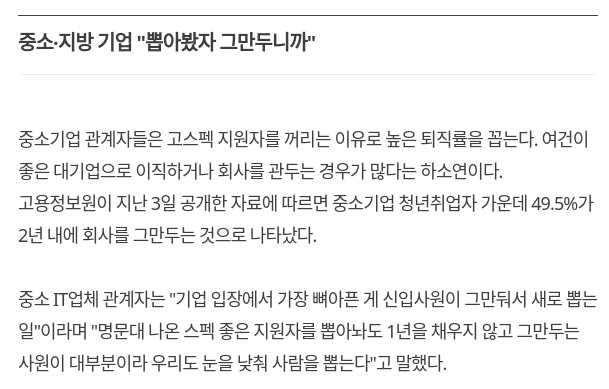

`-` 스펙이 너무 높아도 채용이 안되는 경우도 있다고 한다. 이를 모형화 해보자. 

In [47]:
import numpy as np 
toeic= np.array([300,350,300,
                550,500,530,
                700,750,780,
                985,990])
gpa= np.array([1.1,1.2,1.5, 
              2.1,2.4,2.3,
              3.1,3.2,3.5,
              4.5,4.45])
employed=np.array([0,0,0,
                  1,1,1,
                  2,2,2,
                  0,0])

In [48]:
import pandas as pd 
import seaborn as sns 

In [49]:
df=pd.DataFrame({'toeic':toeic,'gpa':gpa,'employed':employed})

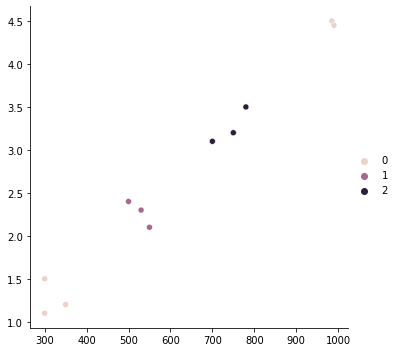

In [50]:
sns.relplot(data=df,x=toeic, y=gpa, hue=employed)

`-` 이는 신경망을 활용하여 학습하기가 불가능해 보인다. 

`-` x:toeic, y:gpa, z:employed 

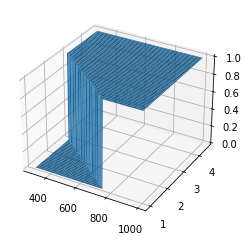

In [51]:
import matplotlib.pyplot as plt 
x1=np.linspace(300,1000,100)
x2=np.linspace(1,4.5,100)
x1,x2 = np.meshgrid(x1,x2)
y= (x1*(0.5/500) + x2*(0.5/2)   > 1 )*1
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
surf= ax.plot_surface(x1,x2,y)

### Multi layers perceptron (MLP)

`–` 해결책: 활성화함수를 몇번 더 취하자. 

`-` 아래처럼 하면? 

$${\bf y} \approx  g\Big(f\big( {\bf X}{\bf W}_1+{\bf b}_1\big){\bf W}_2+{\bf b}_2\Big)$$

In [84]:
X=np.array([toeic,gpa]).transpose()
y=np.array(employed)

In [85]:
from sklearn.preprocessing import * 
onehot=OneHotEncoder()
mms=MinMaxScaler()
mms.fit(X)
X=mms.transform(X)
onehot.fit(y.reshape(-1,1))
y=onehot.transform(y.reshape(-1,1)).toarray()

In [86]:
import tensorflow as tf 
l1=tf.keras.layers.Dense(3,input_shape=(2,),activation='softmax')
l2=tf.keras.layers.Dense(3,activation='softmax')
m1=tf.keras.models.Sequential() 
m1.add(l1) 
m1.add(l2)
m1.compile(loss='categorical_crossentropy')
m1.fit(X,y,epochs=5000,verbose=0)

In [87]:
m1.predict(X).round(3),y

(array([[0.98 , 0.02 , 0.   ],
        [0.968, 0.031, 0.   ],
        [0.97 , 0.03 , 0.   ],
        [0.052, 0.853, 0.095],
        [0.056, 0.857, 0.087],
        [0.043, 0.846, 0.112],
        [0.019, 0.183, 0.797],
        [0.048, 0.112, 0.84 ],
        [0.139, 0.062, 0.799],
        [0.865, 0.002, 0.133],
        [0.864, 0.002, 0.134]], dtype=float32),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.]]))

In [88]:
m1.weights

[<tf.Variable 'dense_24/kernel:0' shape=(2, 3) dtype=float32, numpy=
 array([[ 4.7298656 , -5.664758  ,  0.05853331],
        [ 4.3171325 , -3.0475838 ,  1.2524722 ]], dtype=float32)>,
 <tf.Variable 'dense_24/bias:0' shape=(3,) dtype=float32, numpy=array([-3.6031256,  4.230566 ,  1.461175 ], dtype=float32)>,
 <tf.Variable 'dense_25/kernel:0' shape=(3, 3) dtype=float32, numpy=
 array([[ 1.8002169 , -5.0156765 ,  1.0326893 ],
        [ 5.553367  ,  0.96461076, -4.781076  ],
        [-4.5028462 ,  3.3580093 ,  5.3995705 ]], dtype=float32)>,
 <tf.Variable 'dense_25/bias:0' shape=(3,) dtype=float32, numpy=array([ 0.642925  ,  0.59757906, -1.1739838 ], dtype=float32)>]

In [89]:
tf.nn.softmax(tf.nn.softmax(X@m1.weights[0]+m1.weights[1])@m1.weights[2]+m1.weights[3])

<tf.Tensor: shape=(11, 3), dtype=float32, numpy=
array([[9.80155826e-01, 1.98269524e-02, 1.71367647e-05],
       [9.68491316e-01, 3.14718150e-02, 3.68660149e-05],
       [9.69622910e-01, 3.03424709e-02, 3.46734741e-05],
       [5.21724857e-02, 8.52892578e-01, 9.49349254e-02],
       [5.55786006e-02, 8.56952071e-01, 8.74692649e-02],
       [4.25729565e-02, 8.45645428e-01, 1.11781597e-01],
       [1.92051418e-02, 1.83375776e-01, 7.97419071e-01],
       [4.76609617e-02, 1.12252936e-01, 8.40086043e-01],
       [1.39172167e-01, 6.18002750e-02, 7.99027503e-01],
       [8.64691317e-01, 2.41272058e-03, 1.32896036e-01],
       [8.63808274e-01, 2.43522832e-03, 1.33756474e-01]], dtype=float32)>

### Deep neural network (DNN)

`-` 신경망을 좀더 깊게 쌓으면 더 다양한 구조를 표현할 수 있다. 

`-` 이번에는 MNIST 예제를 분석해보자. 

In [90]:
# 데이터 다운로드
mnist=tf.keras.datasets.mnist
mnistdata=mnist.load_data()

`-` mnistdata는 아래와 같은 구조를 가진다. 
 - `mnistdata` 는 len=2인 튜플이다. 
 - `mnistdata[0]`에는 훈련집합 60000개의 (X,y)가 있다. X는 이미지 (28*28) 이고 y는 이미지의 숫자를 의미하는 0~9까지의 숫자로 구성된 벡터
     - `mnistdata[0][0]`에는 train X 가 있고 `mnistdata[0][1]`에는 train y가 있다. 
     - `mnistdata[1][0]`에는 test X 가 있고 `mnistdata[1][1]`에는 test y가 있다. 
 - `mnistdata[0][0]`= Xtrain : (60000, 28, 28) 
 - `mnistdata[0][1]`= Ytrain : (60000, ) 
 - `mnistdata[1][0]`= Xtrain : (10000, 28, 28) 
 - `mnistdata[1][1]`= Ytrain : (10000,) 

`-` 훈련집합의 1번째 observation의 $X$

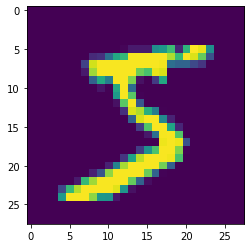

In [91]:
plt.imshow(mnistdata[0][0][0])

`-` 훈련집합의 1번째 observation $y$

In [92]:
mnistdata[0][1][0]

5

`-` 시험집합의 1번째 observation $X$

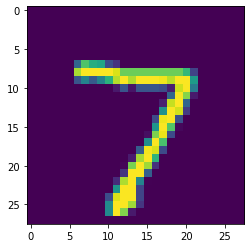

In [93]:
plt.imshow(mnistdata[1][0][0])

`-` 시험집합의 1번째 observation $y$

In [94]:
mnistdata[1][1][0]

7

`-` 가독성을 위해서 자료를 정리하자. 

In [95]:
(Xtrain,Ytrain),(Xtest,Ytest)= mnistdata

7


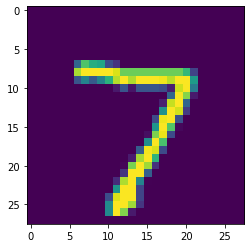

In [96]:
plt.imshow(Xtest[0])
print(Ytest[0])

`-` 훈련집합에서 $\hat{\bf W}$ 를 학습하고 이를 시험집합에서 적용
 - step1: 60000개의 훈련집합 $(X_{train},Y_{train})$에서 적절한 가중치 $\hat{\bf W}$를 추론
 - step2: step1에서 구한 가중치를 활용하여 10000개의 시험집합에서 $X_{test}$만이 주어졌을때 $Y_{test}$를 예측해보고, 그것을 실제값과 비교

`-` 훈련집합 / 시험집합 을 나누었을때 장단점? 
 - 단점: 훈련집합의 수가 적어지므로 학습할 데이터의 수가 적어짐. 
 - 장점: 제대로 훈련을 했는지 test를 해볼 수 있다. ($\to$ 오버피팅을 방지)

`-` 모형이 학습하기 편한형태로 자료를 전처리한다. 

In [97]:
Xtrain=Xtrain/255
Xtest=Xtest/255

In [98]:
Ytrain=tf.keras.utils.to_categorical(Ytrain,10)
Ytest=tf.keras.utils.to_categorical(Ytest,10)

In [99]:
Xtrain=Xtrain.reshape(60000,784)
Xtest=Xtest.reshape(10000,784)

`-` 자료전처리 과정 요약 
 - `reshape`: X의 차원을 $(n,28,28)$에서 $(n,784)$로 변경
 - `tf.keras.utils.to_categorical`: Y의 차원이 $(n,1)$에서 $(n,10)$으로 변경 

`-` 학습한다. 

In [100]:
#(784/128/128/10)
l1=tf.keras.layers.Dense(256,input_shape=(784,),activation='softmax')
l2=tf.keras.layers.Dense(128,activation='softmax')
l3=tf.keras.layers.Dense(10,activation='softmax')
model1=tf.keras.models.Sequential()
model1.add(l1)
model1.add(l2)
model1.add(l3)
model1.compile(loss='categorical_crossentropy')

In [113]:
model1.fit(Xtrain,Ytrain,epochs=50,batch_size=512,steps_per_epoch=100)

Epoch 1/50
100/100 [==============================] - 0s 2ms/step - loss: 0.0996
Epoch 2/50
100/100 [==============================] - 0s 2ms/step - loss: 0.0959
Epoch 3/50
100/100 [==============================] - 0s 3ms/step - loss: 0.0989
Epoch 4/50
100/100 [==============================] - 0s 3ms/step - loss: 0.0966
Epoch 5/50
100/100 [==============================] - 0s 4ms/step - loss: 0.0934
Epoch 6/50
100/100 [==============================] - 1s 6ms/step - loss: 0.0994
Epoch 7/50
100/100 [==============================] - 1s 5ms/step - loss: 0.0953
Epoch 8/50
100/100 [==============================] - 0s 4ms/step - loss: 0.0943
Epoch 9/50
100/100 [==============================] - 0s 4ms/step - loss: 0.0948
Epoch 10/50
100/100 [==============================] - 0s 4ms/step - loss: 0.0944
Epoch 11/50
100/100 [==============================] - 1s 5ms/step - loss: 0.0933
Epoch 12/50
100/100 [==============================] - 1s 5ms/step - loss: 0.0923
Epoch 13/50
100/100 [====

`-` 학습결과를 몇 가지 확인해보자. 

In [102]:
Ytrainhat=model1.predict(Xtrain)
Ytesthat=model1.predict(Xtest)

[0.002 0.003 0.968 0.013 0.003 0.003 0.002 0.003 0.003 0.001]


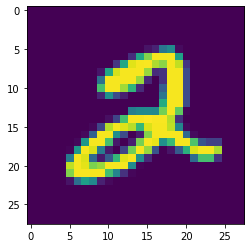

In [103]:
plt.imshow(Xtrain[5].reshape(28,28))
print(Ytrainhat[5].round(3))

[0.001 0.002 0.013 0.013 0.001 0.004 0.003 0.958 0.002 0.003]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


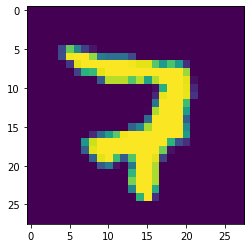

In [104]:
plt.imshow(Xtest[133].reshape(28,28))
print(Ytesthat[133].round(3))
print(Ytest[133].round(3))

`–` 모형을 평가하기 위해서는 

In [105]:
trainloss=model1.evaluate(Xtrain,Ytrain)
testloss=model1.evaluate(Xtest,Ytest)

313/313 [==============================] - 1s 2ms/step - loss: 0.2366


In [106]:
trainloss, testloss

(0.1915990710258484, 0.2366398721933365)